# A quick demo for applying BRIDGE to a delayed transcription-splicing model

We illustrate the idea using a delayed transcription-splicing model. The full model is
$$
D_0 \xleftrightharpoons[\sigma_\text{on}]{\sigma_\text{off}} D_1, 
\qquad 
D_1 \xrightarrow{\rho} D_1+U,
\qquad
U \xRightarrow{\tau} S,
\qquad
S \xrightarrow{d} \varnothing .
$$
Here the gene switches between an inactive state $D_0$ and an active state $D_1$ with rates $\sigma_\text{off}$ and $\sigma_\text{on}$, respectively. When the gene is active, unspliced transcripts $U$ are produced at rate $\rho$. Each unspliced transcript is converted into a spliced transcript $S$ after a fixed processing delay $\tau$, and spliced transcripts are degraded with first-order rate $d$. The corresponding reduced model retains only the transcriptional dynamics of unspliced RNA,
$$
D_0 \xleftrightharpoons[\sigma_\text{on}]{\sigma_\text{off}} D_1, 
\qquad 
D_1 \xrightarrow{\rho} D_1+U,
\qquad
U \xRightarrow{\tau} \varnothing .
$$
The full model is then parametrized by $\varphi_\text{f}=\{\rho,\sigma_\text{on},\sigma_\text{off},d\}$, whereas the reduced model is parametrized by $\varphi_\text{r}=\{\rho,\sigma_\text{on},\sigma_\text{off}\}$. The additional parameter in the full model is therefore the spliced-RNA degradation rate $d$. The goal of BRIDGE is to learn the map from the reduced PGF to the full PGF. The neural network structure, pretraining protocol and inference protocol can be described as

![illustrate](illustrate.png)

For a set of PGF collocation points $\mathbf{z_u}=(z_u^{(1)},\ldots,z_u^{(n_z)})^\top$ and $\mathbf{z_s}=(z_s^{(1)},\ldots,z_s^{(n_z)})^\top$ with $z_u^{(i)},z_s^{(i)}\in[0,1]$, we define the reduced-model PGF vector
$$
\mathbf{g}(\mathbf{z_u}|\varphi_\text{r})
=
\left(
G(z_u^{(1)}|\varphi_\text{r}),
\ldots,
G(z_u^{(n_z)}|\varphi_\text{r})
\right)^\top
\in\mathbb{R}^{n_z}.
$$
The corresponding full-model PGF matrix is given by
$$
\mathbf{G}(\mathbf{z_u},\mathbf{z_s}|\varphi_\text{f})=\left[
G(z_u^{(i)},z_s^{(j)}|\varphi_\text{f})
\right]_{i,j=1}^{n_z}
\in\mathbb{R}^{n_z\times n_z}.
$$
BRIDGE is then represented as
$$
\text{NN}_\xi:
\left(
\mathbf{g}(\mathbf{z_u}|\varphi_\text{r}),\,
\varphi_\text{f}\setminus\varphi_\text{r}
\right)
\mapsto
\text{vec}(\mathbf{G}(\mathbf{z_u},\mathbf{z_s}|\varphi_\text{f})),
$$
where $G(z_u|\varphi_\text{r})$ and $G(z_u,z_s|\varphi_\text{f})$ are the probability generating function of reduced model and full model, respectively.

In practice, we use Gauss-Legendre quadrature to compute the loss function. Let $y_u^{(i)},y_s^{(j)}\in[-1,1]$ be quadrature nodes of order $N_y$, with corresponding weights $w_j$ and $w_k$. 
After mapping the nodes from $[-1,1]$ to $[0,1]$, we set
$$
z_u^{(i)}=\frac{y_u^{(i)}+1}{2},
\qquad
z_s^{(j)}=\frac{y_s^{(j)}+1}{2},
\qquad
n_z=N_y .
$$

In the inference stage, the optimized network $\text{NN}_{\widehat{\xi}}$ is held fixed and used as a differentiable surrogate for the full-model PGF. 
Given experimental count pairs $\{(n_\text{u}^{(i)},n_\text{s}^{(i)})\}_{i=1}^{n_c}$, $n_c$ is the number of count pairs. We compute the empirical PGF matrix $\bar{\mathbf{G}}(\mathbf{z_u},\mathbf{z_s})$. The kinetic parameters of the full model are then inferred by solving
$$
\widehat{\varphi_\text{f}}
=
\arg\min_{\varphi_\text{f}\in\mathcal{D}_{\mathrm{f}}}\frac{1}{4}\mathbf{e}(\varphi_\text{f})^\top(\mathbf{W}\otimes \mathbf{W})\mathbf{e}(\varphi_\text{f})
$$
with
$$
\mathbf{e}(\varphi_\text{f})=\text{NN}_{\widehat{\xi}}
\left[
\mathbf{g}(\mathbf{z_u}|\varphi_\text{r}),
\varphi_\text{f}\setminus\varphi_\text{r}
\right]-\text{vec}\left[
\bar{\mathbf{G}}(\mathbf{z_u},\mathbf{z_s})\right].
$$
where $\mathbf{W}=\operatorname{diag}(w_1,\ldots,w_{N_y})$. Here is the example `Julia` code for parameter inference.

In [13]:
# Import packages
using Optim, Statistics, Distributions, Plots,StatsBase,DelimitedFiles,Random
using FastGaussQuadrature,Flux,DataFrames,CSV,HypergeometricFunctions

In [14]:
# Define Reduced model PGF
function G_tele_delay(σon,σoff,ρ,τ,z)
    u1 = z-1
    r = 1-ρ*u1+σoff+σon
    θ = sqrt(Complex((ρ*u1-σoff-σon)^2+4*ρ*σon*u1))
    uz = (r+θ-1)/2
    uf = (r-θ-1)/2
    G1 = (uz*exp(-uf*τ)-uf*exp(-uz*τ))/θ + ρ*u1*σon*(exp(-uf*τ)-exp(-uz*τ))/(θ*(σoff+σon))
    return real(G1)
end

G_tele_delay (generic function with 1 method)

In [15]:
# Define the function to compute Full model PGF with BRIDGE
function BRIGE_forward(input,ϕf_r,p,re)
    input = vcat(input,ϕf_r)
    output = re(p)(input)
    return output
end

function BRIDGE_compute_full(ps,params,re)
    σon,σoff,ρ = ps[1:3]
    ϕf_r = ps[4:end]
    input = G_tele_delay.(σon,σoff,ρ,1,z1)
    output = BRIGE_forward(input,ϕf_r,params,re)
    return vec(output)
end

BRIDGE_compute_full (generic function with 1 method)

In [16]:
# Define objective function
function int_dist(ps, SSA_PGF, a, W, params, re)
    dist = BRIDGE_compute_full(ps,params,re).^(1+a) .- BRIDGE_compute_full(ps,params,re).^a .* SSA_PGF .* (1+1/a) .+ SSA_PGF / a
    return sum(W .* dist)
end

int_dist (generic function with 1 method)

In [17]:
# Convert 2d distribution to PGF
function hist_gf2d(hist_data,z1,z2)
    Nx = size(hist_data,1)
    Ny = size(hist_data,2)
    z1_vec = [z1.^i for i = 0 : Nx-1]
    z2_vec = [z2.^i for i = 0 : Ny-1]
    z_mat = z1_vec*z2_vec'
    return sum(z_mat.*hist_data)
end

hist_gf2d (generic function with 1 method)

In [18]:
# Define Gaussian Quadrature points and corresponding weights
n = 7
a,b = [0,1]
interval_X, weights = gausslegendre(n)
x = ((b - a) .* interval_X .+ b .+ a) ./ 2
w = weights * (b - a) / 2

z1 = x
z2 = x

W = vec(w*w');

In [19]:
# Define hidden channels
hidden_channels = 40

# Initialize BRIGE model
model = Chain(Dense(length(z1)+1, hidden_channels,tanh),Dense(hidden_channels, length(z1)*length(z2)),x -> softplus.(x))
params, re = Flux.destructure(model);
ps = Flux.params(params);

In [20]:
# Read trained parameters
using CSV,DataFrames
df = CSV.read("parameters_trained/params_trained2d.txt",DataFrame)
params = df.params
ps = Flux.params(params);

In [21]:
# Read inference counts data
# True value is [σ_on,σ_off,ρ,d] =  [0.595,7.335,37.865,0.474]. You can replace it with your own data.
SSA_counts = readdlm("dataset/synthetic_data/counts_example2d.txt")
N_sample = Int.(SSA_counts[:,1])
M_sample = Int.(SSA_counts[:,2])
Sample_size = length(N_sample)

# Convert counts data to joint distribution
NM_sample = [[N_sample[i],M_sample[i]] for i=1:Sample_size]
N_max = Int(maximum([n for (n, m) in NM_sample]))
M_max = Int(maximum([m for (n, m) in NM_sample]))

joint_prob_matrix = zeros(Float64, N_max+1, M_max+1)
for (m, n) in NM_sample
    joint_prob_matrix[m+1, n+1] += 1
end

joint_prob_matrix /= length(NM_sample)

# Convert joint distribution to PGF
SSA_PGF = vec(hist_gf2d(joint_prob_matrix,z1,z2)')

49-element reshape(adjoint(::Matrix{Float64}), 49) with eltype Float64:
 0.06593823763214886
 0.07406410143675492
 0.09173224751262607
 0.12611318140744868
 0.19301363008030448
 0.3201802275114868
 0.503229654035104
 0.06681525667784069
 0.07502516829891992
 0.0928817061120414
 ⋮
 0.4291314753424014
 0.6793401323465137
 0.10473058825469274
 0.1173132671897337
 0.14475873416032656
 0.19851279571427644
 0.30430307514402494
 0.5090225223415775
 0.810476044272307

In [22]:
# Infer parameters
init = [1,1,1,1]
init_ps = log.(init)
itera = 1000
results, time, _,_ = @timed Optim.optimize(ps->int_dist(exp.(ps),SSA_PGF,1.0,W,params,re),init_ps,
Optim.Options(show_trace=false,g_tol=1e-11,iterations = itera)).minimizer

(value = [-0.5137480545196922, 2.052863721740311, 3.685328648342053, -0.7390623434621705], time = 0.344790766, bytes = 80640599, gctime = 0.029650346, gcstats = Base.GC_Diff(80640599, 0, 0, 829548, 3503, 50, 29650346, 1, 0))

In [23]:
# Obtain inferred Parameters
inferred_params = exp.(results)

4-element Vector{Float64}:
  0.598249101234123
  7.790178095906919
 39.85821963535972
  0.47756149430800743

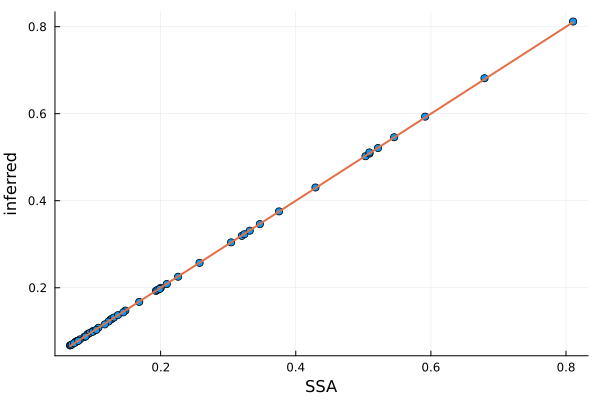

In [24]:
# Check inferred Parameters
inferred_PGF = BRIDGE_compute_full(inferred_params,params,re)
scatter(SSA_PGF,inferred_PGF,xlabel="SSA",ylabel="inferred",legend=:false);
plot!([minimum(SSA_PGF),maximum(SSA_PGF)],[minimum(SSA_PGF),maximum(SSA_PGF)],lw=2,legend=:false)